# Modulo 2 - Regressione
## Notebook Esercizi 


---

In [1]:
# ----------------------------------------------------------------
# CELLA DI SETUP - eseguire questa cella prima di tutte le altre
# ----------------------------------------------------------------

import numpy as np                 # calcolo numerico (array, operazioni matematiche)
import pandas as pd                # tabelle e dataframe
import matplotlib.pyplot as plt    # grafici

# Impostazioni globali dei grafici: dimensione, griglia leggera
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

---
## Unita 2.1 - Regressione Lineare e OLS


### Esercizio 2.1.1 - Dal modello lineare alla stima OLS

**Riferimento:** Unita 2.1 - "Il Modello Lineare", "La Funzione di Perdita: MSE",
"Stima OLS: Le Equazioni Normali"

---

**Il ragionamento**

Come nella slide "Il Modello Lineare" (esempio dell'auto usata), un modello
lineare fa una previsione combinando le feature con dei pesi: cambiando i
pesi cambia la previsione. Ma come troviamo i pesi giusti?

1. Prima proviamo a sceglierli "a occhio": quasi sicuramente l'errore
   (MSE, slide "La Funzione di Perdita: MSE") sara alto.
2. Poi calcoliamo i pesi con le **equazioni normali** (slide "Stima OLS"):
   una formula che restituisce direttamente i pesi che rendono l'MSE il
   piu basso possibile, senza bisogno di procedere per tentativi.

L'esercizio serve a toccare con mano la differenza tra "indovinare" e
"calcolare" i pesi.

---

**Dati:** superficie (mq) e prezzo (k€) di 14 appartamenti (stessa relazione
mostrata nella slide "Cos'e la Regressione?").

**Cosa fare:**
1. Genera `prezzo` con la relazione simulata fornita nel codice
2. Scegli due pesi a caso, `w` e `b`, e calcola le previsioni
   `previsione = w * superficie + b`; calcola l'MSE di questa scelta
3. Costruisci la design matrix X (colonna di 1 + superficie) e calcola i
   pesi ottimali con la formula delle equazioni normali:
   `theta = inv(X.T @ X) @ X.T @ prezzo`
4. Calcola le nuove previsioni e il nuovo MSE, confrontalo con quello del
   punto 2, e disegna entrambe le rette sullo stesso grafico

**Cosa aspettarsi:** l'MSE calcolato con OLS deve risultare sempre minore
o uguale all'MSE dei pesi scelti a caso: nessun'altra scelta di w e b può
fare meglio, su questi dati, dei pesi trovati da OLS.

MSE con pesi scelti a caso: 5270.79
Pesi OLS: intercetta=13.16, peso=2.31
MSE con pesi OLS: 31.97


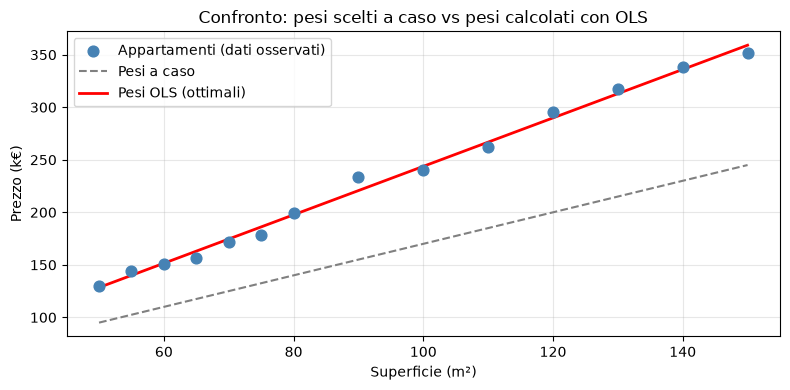

In [2]:
# ----------------------------------------------------------------
# 2.1.1 - Dal modello lineare alla stima OLS
# ----------------------------------------------------------------

# Dati: superficie e prezzo di 14 appartamenti (come nella slide "Cos'e la Regressione?")
superficie = np.array([50, 55, 60, 65, 70, 75, 80, 90, 100, 110, 120, 130, 140, 150], dtype=float)

# Il prezzo vero non lo conosciamo mai in anticipo: qui lo simuliamo con
# rng.normal per aggiungere un rumore casuale attorno a una relazione lineare
rng = np.random.default_rng(7)
prezzo = 2.3 * superficie + 15 + rng.normal(0, 9, size=superficie.shape)

# --- Passo 1: pesi scelti a caso (senza alcun calcolo) ---
w, b = 1.5, 20.0
previsione_a_mano = w * superficie + b            # modello lineare: peso * feature + intercetta

# L'MSE e' la media dei quadrati degli scarti (residui) tra valore osservato e previsto
residui_a_mano = prezzo - previsione_a_mano
mse_a_mano = np.mean(residui_a_mano ** 2)
print("MSE con pesi scelti a caso: {:.2f}".format(mse_a_mano))

# --- Passo 2: equazioni normali (formula chiusa di OLS) ---
# Costruiamo la design matrix: prima colonna di 1 (per l'intercetta b),
# seconda colonna la feature (superficie)
X = np.column_stack([np.ones_like(superficie), superficie])

# np.linalg.inv calcola l'inversa di una matrice: e' il pezzo che serve
# per applicare le equazioni normali e ottenere direttamente i pesi
# ottimali, senza provare piu combinazioni per tentativi.
theta_ols = np.linalg.inv(X.T @ X) @ X.T @ prezzo
intercetta, peso = theta_ols
print("Pesi OLS: intercetta={:.2f}, peso={:.2f}".format(intercetta, peso))

previsione_ols = X @ theta_ols
mse_ols = np.mean((prezzo - previsione_ols) ** 2)
print("MSE con pesi OLS: {:.2f}".format(mse_ols))

# --- Confronto grafico ---
plt.figure()
plt.scatter(superficie, prezzo, color="steelblue", s=60, zorder=5, label="Appartamenti (dati osservati)")
plt.plot(superficie, previsione_a_mano, color="gray", linestyle="--", label="Pesi a caso")
plt.plot(superficie, previsione_ols, color="red", linewidth=2, label="Pesi OLS (ottimali)")
plt.xlabel("Superficie (m²)")
plt.ylabel("Prezzo (k€)")
plt.title("Confronto: pesi scelti a caso vs pesi calcolati con OLS")
plt.legend()
plt.tight_layout()
plt.show()

---
## Unita 2.3 - Gradient Descent

> Riferimento: slide "Perche il Gradient Descent?", "Il Gradiente: Direzione di
> Salita Massima", "Il Ruolo del Learning Rate", "Varianti del Gradient Descent"

Le equazioni normali danno una soluzione esatta in un solo calcolo, ma
diventano costose quando i dati crescono. Il Gradient Descent (come la
discesa da una collina nella nebbia, slide "Perche il Gradient Descent?")
trova la soluzione passo dopo passo, muovendosi nella direzione opposta
al gradiente.

### Esercizio 2.3.1 - Il ruolo del learning rate

**Riferimento:** Unita 2.3 - "Il Gradiente: Direzione di Salita Massima",
"Il Ruolo del Learning Rate"

---

**Il ragionamento**

La slide "Il Gradiente" spiega che il gradiente punta nella direzione in
cui la loss cresce di piu: per minimizzarla ci muoviamo nella direzione
**opposta**. La slide "Il Ruolo del Learning Rate" mostra tre scenari:
passo troppo piccolo (si converge, ma lentamente), passo ottimale
(si converge rapidamente e in modo stabile), passo troppo grande (la
loss oscilla o addirittura peggiora). In questo esercizio riproduciamo
questi tre scenari con i nostri dati.

---

Riutilizza `superficie` e `prezzo` dell'Unita 2.1. Per stabilita numerica,
standardizza prima la superficie: `x = (superficie - media) / dev_std`.

**Cosa fare:**
1. Implementa `gradient_descent(x, y, lr, n_iter)`: ad ogni iterazione
   calcola la previsione, il gradiente della loss (formule nei commenti
   della soluzione), e aggiorna i pesi muovendosi nella direzione
   **opposta** al gradiente
2. Esegui la funzione con tre learning rate: uno piccolo (0.01), uno
   adeguato (0.1), uno troppo grande (1.5)
3. Disegna un grafico con la loss ad ogni iterazione, una linea per
   ciascun learning rate (usa una scala logaritmica sull'asse y)

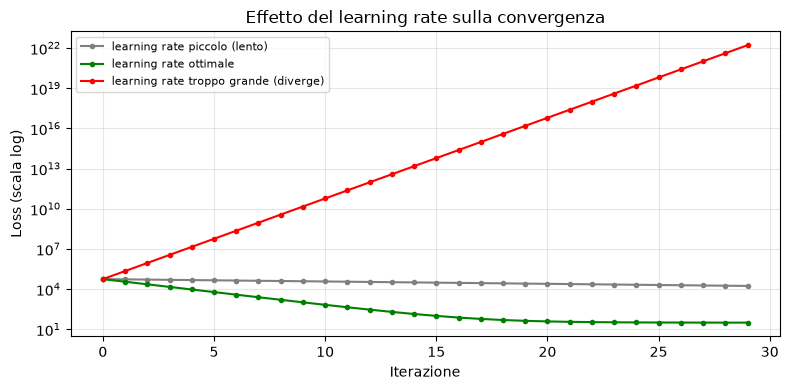

In [6]:
# ----------------------------------------------------------------
# 2.3.1 - Il ruolo del learning rate
# ----------------------------------------------------------------

# Standardizzare significa portare la feature ad avere media 0 e deviazione
# standard 1: rende il Gradient Descent piu stabile e i learning rate
# piu facili da confrontare tra loro
x = (superficie - superficie.mean()) / superficie.std()
y = prezzo.copy()
n = len(x)

def gradient_descent(x, y, lr, n_iter):
    w, b = 0.0, 0.0     # punto di partenza: pesi a zero
    losses = []
    for _ in range(n_iter):
        previsione = w * x + b
        errore = previsione - y
        losses.append(np.mean(errore ** 2))          # loss = MSE corrente

        # Il gradiente della loss MSE rispetto a w e b (quanto la loss
        # cambierebbe se aumentassimo di poco w o b)
        grad_w = (2 / n) * np.sum(errore * x)
        grad_b = (2 / n) * np.sum(errore)

        # Ci muoviamo nella direzione OPPOSTA al gradiente (per questo il segno -):
        # e' la direzione in cui la loss diminuisce, non aumenta
        w -= lr * grad_w
        b -= lr * grad_b
    return w, b, losses

plt.figure()
for lr, colore, etichetta in [(0.01, "gray", "learning rate piccolo (lento)"),
                                (0.1, "green", "learning rate ottimale"),
                                (1.5, "red", "learning rate troppo grande (diverge)")]:
    _, _, losses = gradient_descent(x, y, lr, n_iter=30)
    plt.plot(losses, marker="o", markersize=3, color=colore, label=etichetta)

plt.yscale("log")   # scala log: rende leggibili sia i valori piccoli sia quelli enormi
plt.xlabel("Iterazione")
plt.ylabel("Loss (scala log)")
plt.title("Effetto del learning rate sulla convergenza")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## Unita 2.4 - Regolarizzazione

> Riferimento: slide "Il Problema dell'Overfitting in Regressione", "Ridge
> Regression", "Lasso Regression", "Elastic Net", "Scegliere la penalita"

Con molte feature (o feature correlate tra loro), OLS puo produrre pesi
enormi e instabili: il modello segue il training set quasi alla
perfezione ma generalizza male. Ridge, Lasso ed Elastic Net aggiungono
una penalita alla loss per tenere i pesi sotto controllo.

### Esercizio 2.4.1 - Overfitting: OLS vs Ridge vs Lasso vs Elastic Net

**Riferimento:** Unita 2.4 - "Il Problema dell'Overfitting in Regressione",
"Ridge Regression", "Lasso Regression", "Elastic Net"

---

**Il ragionamento**

La slide "Il Problema dell'Overfitting" mostra che con molte feature OLS
puo produrre pesi molto grandi. La causa tipica e' avere feature che
raccontano quasi la stessa informazione (**multicollinearita**): OLS non
sa a quale delle due "dare credito" e puo assegnare pesi enormi e di
segno opposto. Ridge (slide "Ridge Regression") riduce tutti i pesi ma
raramente li azzera; Lasso (slide "Lasso Regression") puo azzerarli
del tutto, selezionando le feature; Elastic Net (slide "Elastic Net")
sta nel mezzo. In questo esercizio riproduciamo il problema e confrontiamo
le tre soluzioni.

---

**Dati:** dataset simulato con 30 osservazioni e 6 feature, di cui le
prime due sono costruite per essere fortemente correlate tra loro.

**Cosa fare:**
1. Genera il dataset con il codice fornito (`X_reg`, `y_reg`)
2. Allena `LinearRegression()`, `Ridge(alpha=1.0)`, `Lasso(alpha=0.1)` e
   `ElasticNet(alpha=0.1, l1_ratio=0.5)` sugli stessi dati
3. Stampa a confronto i pesi dei quattro modelli
4. Conta quanti pesi sono esattamente zero per Ridge, Lasso ed Elastic Net

In [8]:
# ----------------------------------------------------------------
# 2.4.1 - Overfitting: OLS vs Ridge vs Lasso vs Elastic Net
# ----------------------------------------------------------------

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

rng = np.random.default_rng(3)
n_oss, n_feat = 30, 6
X_reg = rng.normal(size=(n_oss, n_feat))

# La feature 1 e' quasi identica alla feature 0: le rendiamo fortemente
# correlate per riprodurre il problema della multicollinearita
X_reg[:, 1] = X_reg[:, 0] + rng.normal(0, 0.05, n_oss)

vero_beta = np.array([3, -2, 0, 1.5, 0, 0.8])   # pesi "veri" usati per generare i dati
y_reg = X_reg @ vero_beta + rng.normal(0, 1, n_oss)

# .fit(X, y) addestra ciascun modello: la differenza tra i quattro e'
# solo la penalita aggiunta alla loss durante l'addestramento
ols = LinearRegression().fit(X_reg, y_reg)
ridge = Ridge(alpha=1.0).fit(X_reg, y_reg)              # penalita L2 (somma dei quadrati dei pesi)
lasso = Lasso(alpha=0.1).fit(X_reg, y_reg)               # penalita L1 (somma dei valori assoluti)
enet = ElasticNet(alpha=0.1, l1_ratio=0.5).fit(X_reg, y_reg)   # combina L1 e L2

print("{:<12}{}".format("Modello", "Pesi stimati (coef_)"))
print("-" * 70)
print("{:<12}{}".format("Vero beta", np.round(vero_beta, 2)))
print("{:<12}{}".format("OLS", np.round(ols.coef_, 2)))
print("{:<12}{}".format("Ridge", np.round(ridge.coef_, 2)))
print("{:<12}{}".format("Lasso", np.round(lasso.coef_, 2)))
print("{:<12}{}".format("ElasticNet", np.round(enet.coef_, 2)))

# np.isclose confronta con una piccola tolleranza numerica (evita errori
# di arrotondamento): conta quanti pesi sono, di fatto, zero
for nome, modello in [("Ridge", ridge), ("Lasso", lasso), ("ElasticNet", enet)]:
    n_zero = np.sum(np.isclose(modello.coef_, 0))
    print("{}: {} pesi esattamente zero su {}".format(nome, n_zero, len(modello.coef_)))

# Nota: guarda i pesi OLS sulle feature 0 e 1 (quelle correlate):
# sono spesso molto diversi dai pesi veri, anche se la loro somma e'
# simile alla somma dei pesi veri - segno dell'instabilita da multicollinearita

Modello     Pesi stimati (coef_)
----------------------------------------------------------------------
Vero beta   [ 3.  -2.   0.   1.5  0.   0.8]
OLS         [ 5.43 -4.43 -0.17  1.52  0.17  1.15]
Ridge       [ 0.6   0.35 -0.12  1.43  0.17  1.  ]
Lasso       [ 0.84  0.   -0.    1.33  0.09  0.84]
ElasticNet  [ 0.5   0.37 -0.03  1.33  0.12  0.86]
Ridge: 0 pesi esattamente zero su 6
Lasso: 2 pesi esattamente zero su 6
ElasticNet: 0 pesi esattamente zero su 6


### Esercizio 2.4.2 - Scegliere la penalita con la cross-validation

**Riferimento:** Unita 2.4 - "Ridge vs Lasso: Interpretazione Geometrica",
"Scegliere la penalita"

---

**Il ragionamento**

La slide "Ridge vs Lasso: Interpretazione Geometrica" mostra perche Lasso
puo azzerare i pesi (il rombo della penalita L1 ha vertici sugli assi) e
Ridge no (il cerchio della penalita L2 non ha spigoli). La slide
"Scegliere la penalita" spiega poi come scegliere λ: non a caso, ma
provando piu valori con la cross-validation e tenendo quello con errore
di validazione piu basso. In questo esercizio visualizziamo l'effetto di
λ sui pesi Ridge e lasciamo che sia la cross-validation a scegliere il
valore migliore.

---

Riutilizza `X_reg` e `y_reg` dell'esercizio 2.4.1.

**Cosa fare:**
1. Definisci una griglia di valori di λ: `np.logspace(-2, 2, 20)`
2. Per ciascun valore, allena `Ridge(alpha=lam)` e salva i pesi ottenuti
3. Disegna il percorso dei pesi al variare di λ (asse x in scala
   logaritmica): una linea per ciascuna delle 6 feature
4. Usa `RidgeCV(alphas=griglia, cv=5)` per trovare automaticamente il
   miglior λ tramite cross-validation, e stampalo

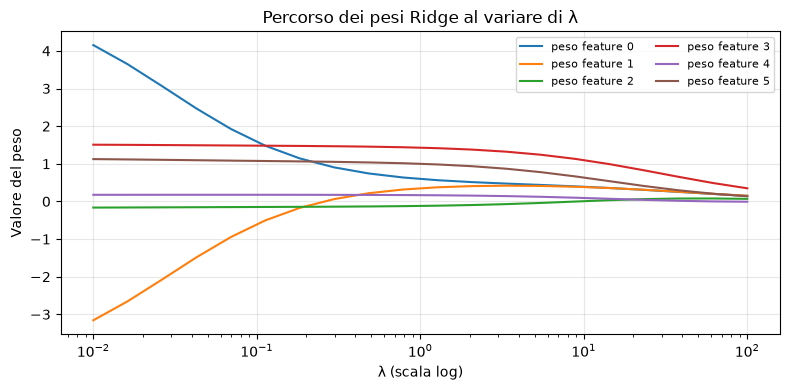

Lambda scelto dalla cross-validation: 0.0100


In [9]:
# ----------------------------------------------------------------
# 2.4.2 - Scegliere la penalita con la cross-validation
# ----------------------------------------------------------------

from sklearn.linear_model import Ridge, RidgeCV

# np.logspace crea una griglia di valori distribuiti logaritmicamente:
# utile perche' l'effetto di lambda si apprezza su ordini di grandezza diversi
griglia_lambda = np.logspace(-2, 2, 20)
percorso_pesi = []

for lam in griglia_lambda:
    modello = Ridge(alpha=lam).fit(X_reg, y_reg)
    percorso_pesi.append(modello.coef_)

percorso_pesi = np.array(percorso_pesi)   # forma: (n_lambda, n_feature)

plt.figure()
for j in range(X_reg.shape[1]):
    plt.plot(griglia_lambda, percorso_pesi[:, j], label="peso feature {}".format(j))
plt.xscale("log")
plt.xlabel("λ (scala log)")
plt.ylabel("Valore del peso")
plt.title("Percorso dei pesi Ridge al variare di λ")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# RidgeCV prova automaticamente tutti i lambda della griglia, valuta ognuno
# con la cross-validation (cv=5 => 5 suddivisioni train/validation), e
# tiene quello con l'errore di validazione medio piu basso
ridge_cv = RidgeCV(alphas=griglia_lambda, cv=5).fit(X_reg, y_reg)
print("Lambda scelto dalla cross-validation: {:.4f}".format(ridge_cv.alpha_))

# Nota il collegamento con la slide "Ridge vs Lasso: Interpretazione
# Geometrica": qui vediamo i pesi Ridge restringersi gradualmente verso
# zero senza mai annullarsi esattamente, coerente con la regione di
# vincolo "a cerchio" (senza spigoli) di Ridge.

---
## Unita 2.5 - Feature Engineering

> Riferimento: slide "Oltre la Retta: Regressione Polinomiale", "Bias-Variance
> Tradeoff", "Pipeline Completa", "Valutare la Regressione", "Regressione
> Multipla: Feature Correlate", "Caso Studio Completo"

Chiudiamo il modulo con la regressione polinomiale, il tradeoff
bias-varianza, e un caso studio completo che mette insieme pipeline,
feature correlate e metriche di valutazione.

### Esercizio 2.5.1 - Regressione polinomiale e bias-varianza

**Riferimento:** Unita 2.5 - "Oltre la Retta: Regressione Polinomiale",
"Bias-Variance Tradeoff", "Grado del Polinomio e Bias-Variance"

---

**Il ragionamento**

La slide "Oltre la Retta" mostra che aggiungendo feature come x al
quadrato, x al cubo, ecc. il modello resta lineare nei pesi ma puo
disegnare curve. La slide "Grado del Polinomio e Bias-Variance" mostra
pero che il grado va scelto con attenzione: troppo basso e il modello
non cattura la curva (**underfitting**, alto bias); troppo alto e il
modello insegue anche il rumore (**overfitting**, alta varianza). Il
modo corretto per scegliere il grado e' confrontare l'errore su dati
**mai usati in addestramento** (test set), non l'errore di training.

---

**Dati:** relazione quadratica con rumore, `x` in [-3, 3].

**Cosa fare:**
1. Genera il dataset e dividilo in training e test con `train_test_split`
   (`test_size=0.3`)
2. Per gradi da 1 a 10, trasforma la feature con `PolynomialFeatures`,
   allena una `LinearRegression`, calcola l'MSE su training e su test
3. Disegna un grafico con le due curve di errore (training e test) al
   variare del grado, e individua il grado con errore di test minimo

Grado che minimizza l'errore di test: 2


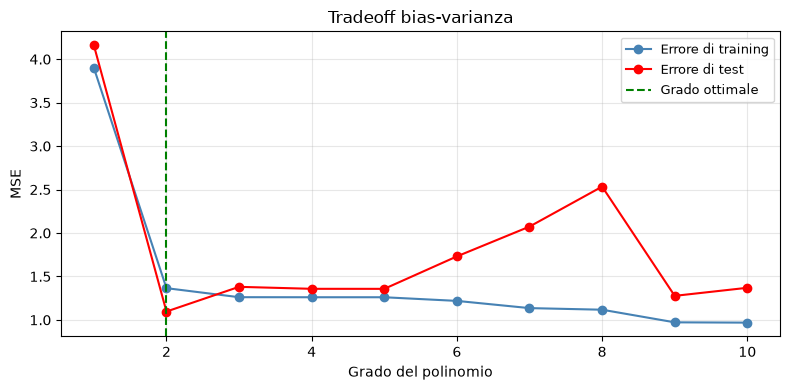

In [10]:
# ----------------------------------------------------------------
# 2.5.1 - Regressione polinomiale e bias-varianza
# ----------------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(11)
x_poly = np.linspace(-3, 3, 60)
y_poly = 0.5 * x_poly ** 2 - x_poly + 2 + rng.normal(0, 1.3, size=x_poly.shape)
X_poly = x_poly.reshape(-1, 1)   # scikit-learn vuole le feature come colonna

# train_test_split divide casualmente i dati in due gruppi: l'80%... qui il
# 70% (test_size=0.3 lascia il 30% al test) va in training, il resto in test.
# random_state fissa il seme casuale, cosi il risultato e' riproducibile
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y_poly, test_size=0.3, random_state=42)

gradi = range(1, 11)
errore_train, errore_test = [], []

for d in gradi:
    # PolynomialFeatures crea, a partire da x, nuove colonne con le potenze
    # successive di x fino al grado d: il modello resta lineare, ma lavora
    # in uno spazio di feature piu ricco
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_d = poly.fit_transform(X_train)   # calcola e applica la trasformazione sul training
    X_test_d = poly.transform(X_test)         # applica la STESSA trasformazione al test

    modello = LinearRegression().fit(X_train_d, y_train)
    errore_train.append(mean_squared_error(y_train, modello.predict(X_train_d)))
    errore_test.append(mean_squared_error(y_test, modello.predict(X_test_d)))

grado_migliore = list(gradi)[np.argmin(errore_test)]
print("Grado che minimizza l'errore di test: {}".format(grado_migliore))

plt.figure()
plt.plot(list(gradi), errore_train, marker="o", color="steelblue", label="Errore di training")
plt.plot(list(gradi), errore_test, marker="o", color="red", label="Errore di test")
plt.axvline(grado_migliore, color="green", linestyle="--", label="Grado ottimale")
plt.xlabel("Grado del polinomio")
plt.ylabel("MSE")
plt.title("Tradeoff bias-varianza")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Esercizio 2.5.2 - Caso studio: pipeline, feature correlate e metriche

**Riferimento:** Unita 2.5 - "Pipeline Completa", "Valutare la Regressione:
Recap delle Metriche", "Regressione Multipla: Feature Correlate",
"Caso Studio Completo: Previsione Prezzi Immobiliari"

---

**Il ragionamento**

Questo esercizio mette insieme gli ultimi concetti della slide "Caso
Studio Completo": prima si controllano le correlazioni tra le feature
(slide "Regressione Multipla: Feature Correlate" - feature quasi
duplicate rendono instabili i pesi), poi si costruisce una pipeline che
applica sempre nello stesso ordine standardizzazione e modello (slide
"Pipeline Completa"), infine si valuta il risultato con piu di una
metrica (slide "Valutare la Regressione": MAE, RMSE, R²), perche ognuna
racconta un aspetto diverso dell'errore.

---

**Dati:** dataset simulato di 150 appartamenti con tre feature
(superficie, numero di vani, eta dell'edificio). Nota: superficie e vani
sono costruite per essere correlate, per riprodurre una situazione
realistica.

**Cosa fare:**
1. Genera il dataset con il codice fornito e costruiscilo come DataFrame
2. Calcola la matrice di correlazione (`df.corr()`) e individua la coppia
   di feature piu correlata
3. Dividi in train/test, poi costruisci una `Pipeline` con due passi:
   `StandardScaler` (standardizzazione) e `Ridge(alpha=10)`
4. Calcola sul test set le tre metriche R², MAE, RMSE

In [11]:
# ----------------------------------------------------------------
# 2.5.2 - Caso studio: pipeline, feature correlate e metriche
# ----------------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

rng = np.random.default_rng(99)
n_case = 150
superficie_c = rng.uniform(40, 180, n_case)
# vani e' costruita a partire dalla superficie: le due feature sono percio' correlate
vani_c = np.round(superficie_c / 28 + rng.normal(0, 0.4, n_case)).clip(1, 7)
eta_edificio = rng.uniform(0, 50, n_case)

prezzo_casa = (
    1600 * superficie_c
    + 6000 * vani_c
    - 300 * eta_edificio
    + rng.normal(0, 12000, n_case)
)

df_case = pd.DataFrame({
    "Superficie": superficie_c,
    "Vani": vani_c,
    "Eta": eta_edificio,
    "Prezzo": prezzo_casa,
})

# .corr() calcola la correlazione tra ogni coppia di colonne: valori vicini
# a +1 o -1 indicano una relazione lineare forte (qui e' attesa tra
# Superficie e Vani, essendo state costruite l'una in funzione dell'altra)
print(df_case.corr().round(2))

X_case = df_case[["Superficie", "Vani", "Eta"]].values
y_case = df_case["Prezzo"].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_case, y_case, test_size=0.2, random_state=42)

# Una Pipeline concatena piu passaggi in un unico oggetto: qui prima
# standardizza le feature (media 0, deviazione standard 1), poi applica
# Ridge. Il vantaggio e' che la STESSA trasformazione, appresa sul
# training, viene applicata automaticamente anche in fase di previsione
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10)),
])
pipeline.fit(X_train_c, y_train_c)
previsioni_test = pipeline.predict(X_test_c)

# Tre metriche diverse, come nella slide "Valutare la Regressione":
r2 = r2_score(y_test_c, previsioni_test)                              # quanta variabilita' spiega il modello (1 = perfetto)
mae = mean_absolute_error(y_test_c, previsioni_test)                  # errore medio assoluto, facile da leggere
rmse = mean_squared_error(y_test_c, previsioni_test) ** 0.5           # penalizza di piu' gli errori grandi

print("R²:   {:.3f}".format(r2))
print("MAE:  {:.1f} €".format(mae))
print("RMSE: {:.1f} €".format(rmse))

            Superficie  Vani   Eta  Prezzo
Superficie        1.00  0.94 -0.03    0.98
Vani              0.94  1.00 -0.01    0.94
Eta              -0.03 -0.01  1.00   -0.09
Prezzo            0.98  0.94 -0.09    1.00
R²:   0.960
MAE:  10965.2 €
RMSE: 13242.2 €
